Using Gemini, Learning LangChain Framework and Tracking with LangSmith

REF :
- https://python.langchain.com/docs/integrations/chat/google_generative_ai/

####Call Google-generative (Gemini) API

In [ ]:
!pip install -qU langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-generativeai 0.8.5 requires google-ai-generativelanguage==0.6.15, but you have google-ai-generativelanguage 0.6.18 which is incompatible.


In [ ]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

Enter your Google AI API key: ··········


In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

To enable automated tracing of your model calls, set your [LangSmith](https://smith.langchain.com/) API key:

In [ ]:
os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")


Enter your LangSmith API key: ··········


Just run this line, LangSmith will automatically track your runs.

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"

All LLM executions in this Google Colab will be logged on the LangSmith website.

####Simple Invocation

In [ ]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg

AIMessage(content="J'aime la programmation.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--99b093d5-1e35-4618-995b-c4bf4655a067-0', usage_metadata={'input_tokens': 21, 'output_tokens': 60, 'total_tokens': 81, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 53}})

In [ ]:
print(ai_msg.content)

J'aime la programmation.


- Check automated log in LangSmith website.

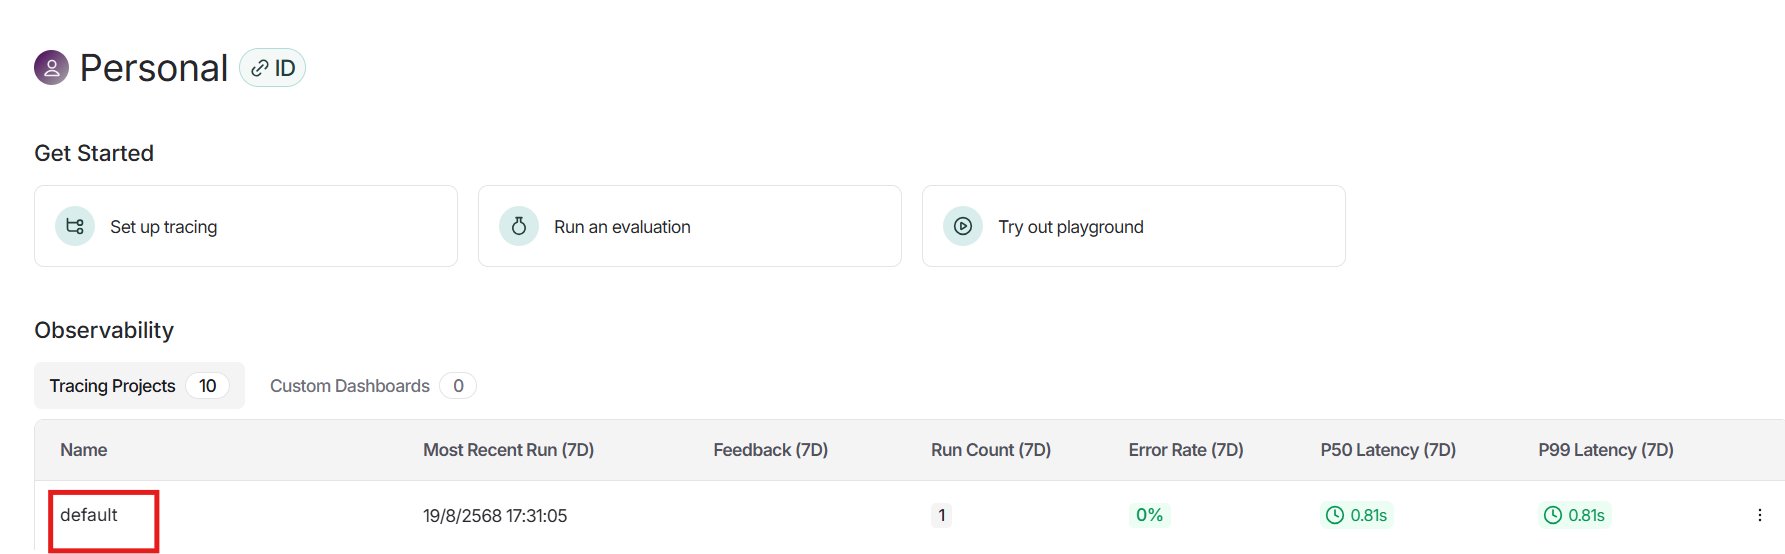

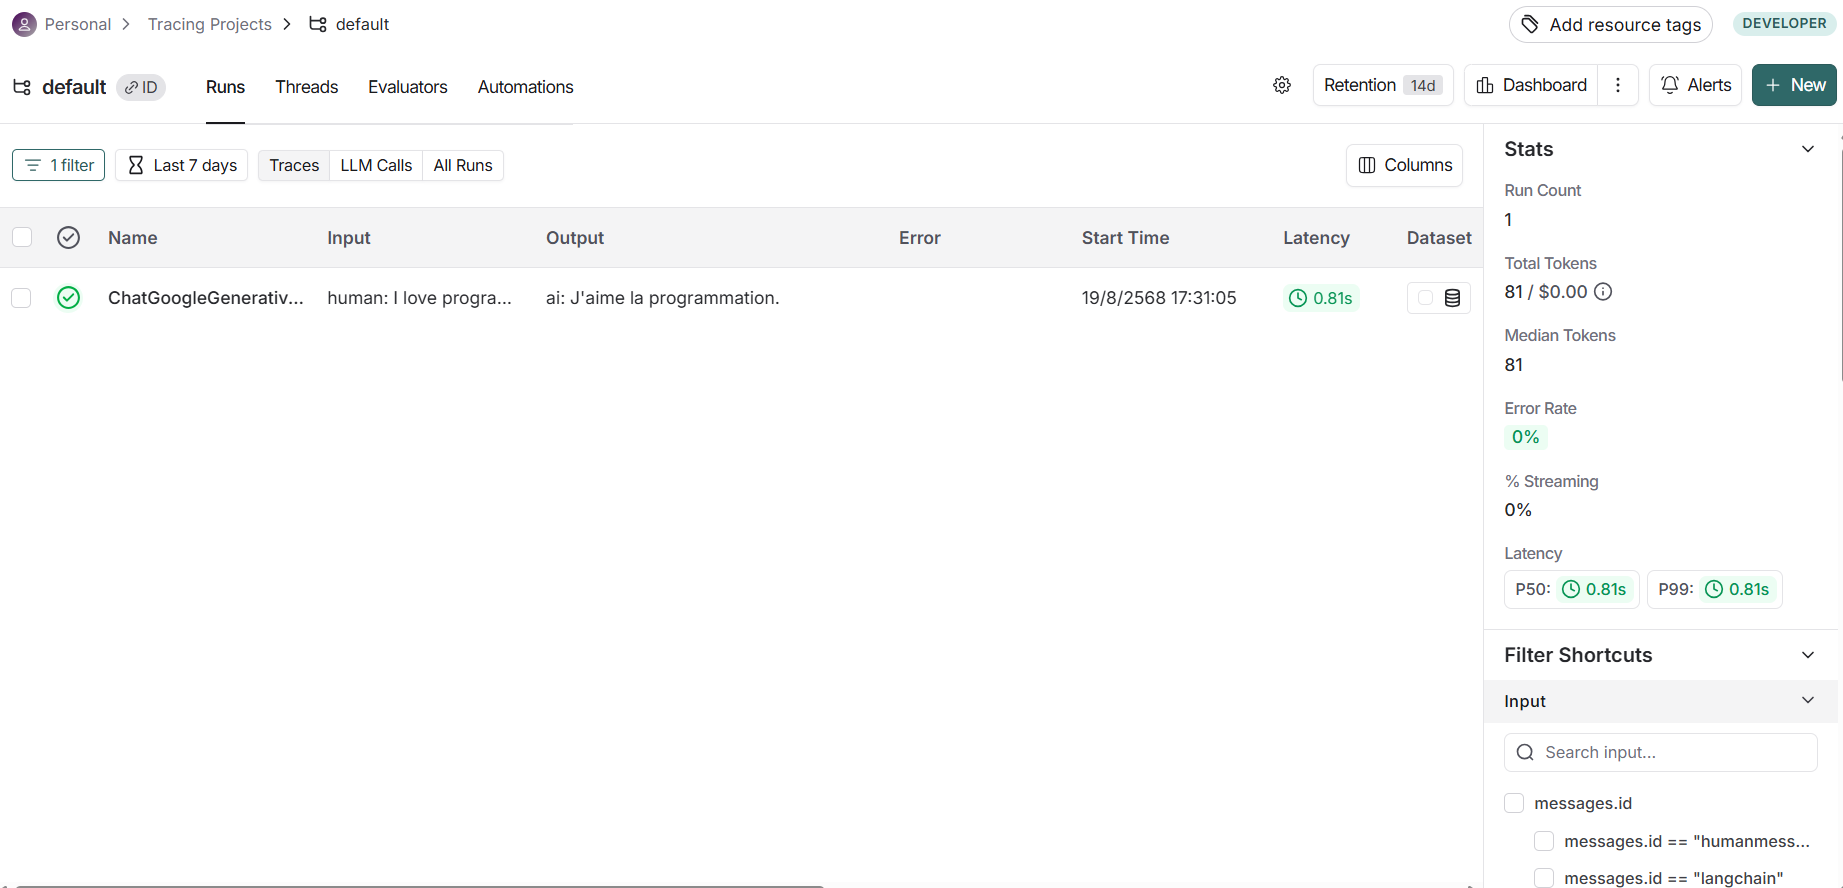

####Chaining

- LangChain supports pipe operator.
- ex. `prompt | llm`

  - Receive input from the user → insert it into the prompt (template/formatter)
  - The result from the prompt → is passed to the LLM (model)
  - The output from the model → becomes the final answer

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(  # prompt template contains three fields : input_language, output_language, input
    [
        (
            "system",
            "You are a helpful assistant that translates {input_language} to {output_language}.",
        ),
        ("human", "{input}"),
    ]
)

chain = prompt | llm # this line !
chain.invoke(
    {
        "input_language": "English", # this input_language from user is passed into defined prompt template, in this case, input_language = 'English'
        "output_language": "German", # this output_language from user is passed into defined prompt template, in this case, input_language = 'German'
        "input": "I love programming.", # this input from user is passed into defined prompt template, in this case, input_language = 'I love programming'
    }
)

AIMessage(content='Ich liebe das Programmieren.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--f09b8ee7-c6c6-47d6-a9f1-3d90f73ed91e-0', usage_metadata={'input_tokens': 16, 'output_tokens': 196, 'total_tokens': 212, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 190}})

####Multimodal Usage

#####Image

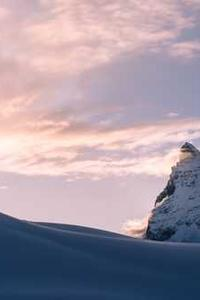

In [ ]:
import base64 # for encoding an image file into a text-like format (base64)

from langchain_core.messages import HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI

# Example using a public URL (remains the same)
message_url = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe the image at the URL.",
        },
        {"type": "image_url", "image_url": "https://picsum.photos/seed/picsum/200/300"},
    ]
)
result_url = llm.invoke([message_url])
print(f"Response for URL image: {result_url.content}")

Response for URL image: This image captures a serene and majestic winter landscape, likely at either sunrise or sunset, given the colors of the sky.

Here's a breakdown:

*   **Sky:** The upper two-thirds of the image are dominated by a beautiful, soft pastel sky. It features a gradient of colors, transitioning from light pinks and oranges near what would be the horizon (implied lower left) to soft purples and lavender hues higher up. Wispy, elongated clouds are scattered across the sky, catching the warm light and adding texture.
*   **Snowy Landscape:** The lower third of the image consists of a vast expanse of snow. This snow is rendered in deep shades of blue and indigo, indicating it is largely in shadow, creating a strong contrast with the brightly lit sky. The snow appears smooth and undulating, forming gentle curves.
*   **Mountain Peak:** On the far right side of the image, a sharp, snow-capped mountain peak rises. The very tip and the right side of this peak are brightly illu

#####Audio

1. Download this audio file from Kaggle (https://www.kaggle.com/datasets/pavanelisetty/sample-audio-files-for-speech-recognition?resource=download)
2. Upload the file into this Google Colab
3. Unzip the file using the code below

In [ ]:
!unzip /content/harvard.wav.zip harvard.wav

Archive:  /content/harvard.wav.zip
  inflating: harvard.wav             


In [ ]:
import base64 # for encoding an audio file into a text-like format (base64)

from langchain_core.messages import HumanMessage

audio_file_path = "harvard.wav"
audio_mime_type = "audio/wav" # change it to your audio file type


with open(audio_file_path, "rb") as audio_file:
    encoded_audio = base64.b64encode(audio_file.read()).decode("utf-8")

message = HumanMessage(
    content=[
        {"type": "text", "text": "Transcribe the audio."},
        {
            "type": "media",
            "data": encoded_audio,  # Use base64 string directly
            "mime_type": audio_mime_type,
        },
    ]
)
response = llm.invoke([message])  # Uncomment to run
print(f"Response for audio: {response.content}")

Response for audio: The stale smell of old beer lingers. It takes heat to bring out the odor. A cold dip restores health and zest. A salt pickle tastes fine with ham. Tacos al pastor are my favorite. A zestful food is the hot cross bun.


####Token Usage Tracking

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

result = llm.invoke("Explain the concept of prompt engineering in one sentence.")

print(result.content)
print("\nUsage Metadata:")
print(result.usage_metadata)

Prompt engineering is the process of designing, refining, and optimizing inputs (prompts) for AI models to guide their behavior and elicit specific, desired, and high-quality outputs.

Usage Metadata:
{'input_tokens': 11, 'output_tokens': 661, 'total_tokens': 672, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 625}}


####Structured Output via Pydantic

- Pydantic class (`pydantic_v1`) → used for structured output (can be combined with prompting for better results).

- It defines the schema of the output (e.g., which fields exist and what types they should have).

- LangChain can then enforce the LLM to generate output that conforms to the schema.

In [ ]:
from langchain_core.pydantic_v1 import BaseModel, Field
# Define the desired schema
class Person(BaseModel):
    """Information about a person."""

    name: str = Field(..., description="The person's name")
    height_m: float = Field(..., description="The person's height in meters")

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the model
llm = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0)
structured_llm = llm.with_structured_output(Person) # plug defined schema here

result = structured_llm.invoke(
    "Who was the 16th president of the USA, and how tall was he in meters?"
)
print(result)

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


name='Abraham Lincoln' height_m=1.93


In [ ]:
print(result)

name='Abraham Lincoln' height_m=1.93


From the defined ```Pydantic object```, we can convert it into ```JSON``` as follows:

In [ ]:
print(result.json())

{"name": "Abraham Lincoln", "height_m": 1.93}


####Function Calling (Custom Function)

In [ ]:
from langchain_core.tools import tool

# Define the tool
@tool(description="Get the current weather in a given location")
def get_weather(location: str) -> str:
    return "It's sunny."

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the model and bind the tool
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm_with_tools = llm.bind_tools([get_weather])  # bind our LLM with defined tool

In [ ]:
# Invoke the model with a query that should trigger the tool
query = "What's the weather in San Francisco?"
ai_msg = llm_with_tools.invoke(query)

In [ ]:
print(ai_msg)

content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "San Francisco"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []} id='run--3e6642d2-697a-4407-bf5d-a573533dd55f-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'San Francisco'}, 'id': '388fc1e7-b4ef-48bc-baaf-6773043f6275', 'type': 'tool_call'}] usage_metadata={'input_tokens': 50, 'output_tokens': 57, 'total_tokens': 107, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 41}}


You have received a response like this:
- ```content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "San Francisco"}'}} ...```


- The LLM response is a function call message with the argument: location = 'San Francisco'.

In [ ]:
print(ai_msg.tool_calls[0]) # tool message

{'name': 'get_weather', 'args': {'location': 'San Francisco'}, 'id': '388fc1e7-b4ef-48bc-baaf-6773043f6275', 'type': 'tool_call'}


In [ ]:
# Example tool call message would be needed here if you were actually running the tool
from langchain_core.messages import ToolMessage

tool_message = ToolMessage(
    content=get_weather(*ai_msg.tool_calls[0]["args"]),
    tool_call_id=ai_msg.tool_calls[0]["id"], #
)

In [ ]:
tool_message

ToolMessage(content="It's sunny.", tool_call_id='388fc1e7-b4ef-48bc-baaf-6773043f6275')

- ToolMessage is an object that packages the result of a tool call.

- The arguments are passed to the function you defined (e.g., get_weather).

- The function’s output is stored as content.

- The id is stored as tool_call_id to link the result back to the correct tool call from the LLM.

In [ ]:
tool_message

ToolMessage(content="It's sunny.", tool_call_id='388fc1e7-b4ef-48bc-baaf-6773043f6275')

In [ ]:
llm_with_tools.invoke([HumanMessage(query), ai_msg, tool_message])  # Passing tool result back, let LLM create a final response

AIMessage(content='The weather in San Francisco is sunny.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--ad316d90-d48a-4afd-95f7-6eaf6e2da30d-0', usage_metadata={'input_tokens': 85, 'output_tokens': 8, 'total_tokens': 93, 'input_token_details': {'cache_read': 0}})

##### Additional : Prebuilt Tools (Ex. Google Search Engine)

In [ ]:
from google.ai.generativelanguage_v1beta.types import Tool as GenAITool # import a prebuilt tool from library

resp = llm.invoke(
    "When is the next total solar eclipse in US?",
    tools=[GenAITool(google_search={})],
)

print(resp.content)

The next total solar eclipse visible in the United States will occur on March 30, 2033, though its path of totality will be limited to Alaska.

For the contiguous United States, the next total solar eclipse will take place on August 23, 2044, crossing parts of Montana, North Dakota, and South Dakota. Following that, a significant "coast-to-coast" total solar eclipse will sweep across the US on August 12, 2045, with its path stretching from California to Florida.


In [ ]:
resp # raw response

AIMessage(content='The next total solar eclipse visible in the United States will occur on March 30, 2033, though its path of totality will be limited to Alaska.\n\nFor the contiguous United States, the next total solar eclipse will take place on August 23, 2044, crossing parts of Montana, North Dakota, and South Dakota. Following that, a significant "coast-to-coast" total solar eclipse will sweep across the US on August 12, 2045, with its path stretching from California to Florida.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'grounding_metadata': {'search_entry_point': {'rendered_content': '<style>\n.container {\n  align-items: center;\n  border-radius: 8px;\n  display: flex;\n  font-family: Google Sans, Roboto, sans-serif;\n  font-size: 14px;\n  line-height: 20px;\n  padding: 8px 12px;\n}\n.chip {\n  display: inline-block;\n  border: solid 1px;

- Google Search’s output comes with metadata for citation (but it needs to be post-processed programmatically).

In [ ]:
resp.response_metadata

{'prompt_feedback': {'block_reason': 0, 'safety_ratings': []},
 'finish_reason': 'STOP',
 'model_name': 'gemini-2.5-flash',
 'safety_ratings': [],
 'grounding_metadata': {'search_entry_point': {'rendered_content': '<style>\n.container {\n  align-items: center;\n  border-radius: 8px;\n  display: flex;\n  font-family: Google Sans, Roboto, sans-serif;\n  font-size: 14px;\n  line-height: 20px;\n  padding: 8px 12px;\n}\n.chip {\n  display: inline-block;\n  border: solid 1px;\n  border-radius: 16px;\n  min-width: 14px;\n  padding: 5px 16px;\n  text-align: center;\n  user-select: none;\n  margin: 0 8px;\n  -webkit-tap-highlight-color: transparent;\n}\n.carousel {\n  overflow: auto;\n  scrollbar-width: none;\n  white-space: nowrap;\n  margin-right: -12px;\n}\n.headline {\n  display: flex;\n  margin-right: 4px;\n}\n.gradient-container {\n  position: relative;\n}\n.gradient {\n  position: absolute;\n  transform: translate(3px, -9px);\n  height: 36px;\n  width: 9px;\n}\n@media (prefers-color-sche

In [ ]:
resp.response_metadata['grounding_metadata']

{'search_entry_point': {'rendered_content': '<style>\n.container {\n  align-items: center;\n  border-radius: 8px;\n  display: flex;\n  font-family: Google Sans, Roboto, sans-serif;\n  font-size: 14px;\n  line-height: 20px;\n  padding: 8px 12px;\n}\n.chip {\n  display: inline-block;\n  border: solid 1px;\n  border-radius: 16px;\n  min-width: 14px;\n  padding: 5px 16px;\n  text-align: center;\n  user-select: none;\n  margin: 0 8px;\n  -webkit-tap-highlight-color: transparent;\n}\n.carousel {\n  overflow: auto;\n  scrollbar-width: none;\n  white-space: nowrap;\n  margin-right: -12px;\n}\n.headline {\n  display: flex;\n  margin-right: 4px;\n}\n.gradient-container {\n  position: relative;\n}\n.gradient {\n  position: absolute;\n  transform: translate(3px, -9px);\n  height: 36px;\n  width: 9px;\n}\n@media (prefers-color-scheme: light) {\n  .container {\n    background-color: #fafafa;\n    box-shadow: 0 0 0 1px #0000000f;\n  }\n  .headline-label {\n    color: #1f1f1f;\n  }\n  .chip {\n    bac

In [ ]:
supports = resp.response_metadata['grounding_metadata']['grounding_supports']

In [ ]:
supports # indicates start_index, stop_index for sections, for citation

[{'segment': {'end_index': 141,
   'text': 'The next total solar eclipse visible in the United States will occur on March 30, 2033, though its path of totality will be limited to Alaska',
   'part_index': 0,
   'start_index': 0},
  'grounding_chunk_indices': [0, 1],
  'confidence_scores': []},
 {'segment': {'start_index': 144,
   'end_index': 300,
   'text': 'For the contiguous United States, the next total solar eclipse will take place on August 23, 2044, crossing parts of Montana, North Dakota, and South Dakota',
   'part_index': 0},
  'grounding_chunk_indices': [2],
  'confidence_scores': []},
 {'segment': {'start_index': 302,
   'end_index': 465,
   'text': 'Following that, a significant "coast-to-coast" total solar eclipse will sweep across the US on August 12, 2045, with its path stretching from California to Florida',
   'part_index': 0},
  'grounding_chunk_indices': [2, 1],
  'confidence_scores': []}]

In [ ]:
sorted_supports = sorted(supports, key=lambda s: s['segment']['end_index'], reverse=True)

In [ ]:
sorted_supports[0]

{'segment': {'start_index': 302,
  'end_index': 465,
  'text': 'Following that, a significant "coast-to-coast" total solar eclipse will sweep across the US on August 12, 2045, with its path stretching from California to Florida',
  'part_index': 0},
 'grounding_chunk_indices': [2, 1],
 'confidence_scores': []}

In [ ]:
def add_citations(resp):
    text = resp.content
    supports = resp.response_metadata['grounding_metadata']['grounding_supports']
    chunks = resp.response_metadata['grounding_metadata']['grounding_chunks']

    # Sort supports by end_index in descending order to avoid shifting issues when inserting.
    sorted_supports = sorted(supports, key=lambda s: s['segment']['end_index'], reverse=True)

    for support in sorted_supports:
        end_index = support['segment']['end_index']
        if support['grounding_chunk_indices']:
            # Create citation string like [1](link1)[2](link2)
            citation_links = []
            for i in support['grounding_chunk_indices']:
                if i < len(chunks):
                    uri = chunks[i]['web']['uri']
                    citation_links.append(f"[{i + 1}]({uri})")

            citation_string = ", ".join(citation_links)
            text = text[:end_index] + citation_string + text[end_index:]

    return text

In [ ]:
# Assuming response with grounding metadata
text_with_citations = add_citations(resp)
print(text_with_citations)

The next total solar eclipse visible in the United States will occur on March 30, 2033, though its path of totality will be limited to Alaska[1](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQFh106x97IsCDaKxa4KqGhlgK_enbwKjQyKvqNlxyIAUTO8IXXemnJjAJEW8cKv5QbSboSICwsIzE_VWpe9HrAcS_--n8daeHL3nEmGn29kYiJQJjd9SWHgmcqJhuJogZcQ_dpmgYaLcQHLy3UWSMfvJb7liD_N56ZM6UdcVGBPzBH0KV6vEZ4ps_xarcI=), [2](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQH6d6WSfZ5xgegWUVMEC4_UfrReMlA_cZHQKgbSisaj281BJvS5X1-qOgeFbUiVSZmNyqHuafFdgJhV9so-jyYDPrLdz2mT3WGPS2vyEOKGlen6MAjQ9sIiBhXJUmj8h857m7ZXPkOuv4HgvxcaGKogeQzO7vjQYCMQ9CShJK8l6QlCpjb3WFm_-cB4Bx0qJcL76gccij3arvw-n0sfY31J5HMqBOxh-n_oIDGe5YLWPbkMxHFtSnC-tD2F30VOrvw=).

For the contiguous United States, the next total solar eclipse will take place on August 23, 2044, crossing parts of Montana, North Dakota, and South Dakota[3](https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQG2njLY2HV7fAVoKsbvLXJK1CZ6RgI

- The response with citations showed here.